# Feature Importance From Saved Models
This notebook loads saved model weights from `models/trained/*.pkl`, rebuilds the matching GNN architectures, and computes permutation feature importance without rerunning training.

By default it evaluates on the full CSV dataset because the original training notebook did not persist train/val/test indices alongside the `.pkl` files. If you want a split-based evaluation, change `EVALUATION_SPLIT` in the configuration cell.

In [18]:
import importlib.util
import subprocess
import sys

required_packages = [
    "pandas>=2.2.3",
    "pandapower",
    "numpy",
    "torch",
    "torchvision",
    "torchaudio",
    "torch_geometric",
    "h5py",
    "matplotlib",
    "seaborn",
]

if importlib.util.find_spec("pip") is None:
    raise RuntimeError(
        "pip is not available in this notebook kernel. Select the project virtual environment kernel before running this notebook."
    )

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])

0

In [19]:
import os
import sys
import pickle
from pathlib import Path
from typing import Sequence, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Subset, random_split
from torch_geometric.data.data import BaseData
from torch_geometric.loader import DataLoader

def ensure_project_root():
    candidate_roots = [
        Path.cwd(),
        Path.cwd() / "nodal-gnn",
        Path(r"c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn"),
    ]

    for root in candidate_roots:
        if (root / "ieee_dataset.py").exists() and (root / "models" / "__init__.py").exists():
            if str(root) not in sys.path:
                sys.path.insert(0, str(root))
            os.chdir(root)
            return root

    checked = "\n".join(str(path) for path in candidate_roots)
    raise FileNotFoundError(f"Unable to locate the nodal-gnn project folder. Checked:\n{checked}")

project_root = ensure_project_root()
print(f"Using project root: {project_root}")

from ieee_dataset import IEEECongestionCSVDataset
from models.gcn_model import GCNEdgePredictor
from models.graphsage_model import GraphSAGEEdgePredictor
from models.gat_model import GATEdgePredictor
from models.mpnn_model import MPNNEdgePredictor
from models.ecgnn_model import ECGNNEdgePredictor
from models.pinn_model import PINNEdgePredictor

Using project root: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn


In [20]:
EVALUATION_SPLIT = "full"  # one of: full, train, val, test
SPLIT_SEED = 42

QUICK_MODE = True  # True = faster diagnostics
FEATURE_IMPORTANCE_BATCH_SIZE = 1024 if QUICK_MODE else 256
FEATURE_IMPORTANCE_REPEATS = 2 if QUICK_MODE else 5
MAX_EVAL_SAMPLES = 10000 if QUICK_MODE else None  # cap sample count for speed

TARGET_MODELS = ["ECGNN"]  # set to [] to evaluate all available models

NODE_FEATURE_NAMES = [
    "Pd",
    "Qd",
    "gen_status",
    "pgmax",
    "pgmin",
    "degree_centrality",
]

EDGE_FEATURE_MAP = {
    "smax": "smax",
    "status": "branch_status",
    "b": "susceptance_b",
}

MODEL_REGISTRY = {
    "GraphSAGE": GraphSAGEEdgePredictor,
    "GAT": GATEdgePredictor,
    "MPNN": MPNNEdgePredictor,
    "ECGNN": ECGNNEdgePredictor,
}

trained_dir = project_root / "models" / "trained"
results_dir = project_root / "results" / "feature_importance"
results_dir.mkdir(parents=True, exist_ok=True)

def resolve_case_path():
    candidates = [
        os.environ.get("CSML_CASE_PATH"),
        str(project_root / "case.json"),
        str(project_root / "PGLearn-Small-57_ieee-nminus1" / "case.json"),
    ]

    for candidate in candidates:
        if candidate and Path(candidate).exists():
            os.environ["CSML_CASE_PATH"] = candidate
            return Path(candidate)

    checked = "\n".join(path for path in candidates if path)
    raise FileNotFoundError(f"Unable to locate case.json. Checked:\n{checked}")

def resolve_csv_path():
    dataset_name = "congestion_dataset_v5.csv"
    candidates = [
        os.environ.get("CONGESTION_DATASET_PATH"),
        str(project_root / dataset_name),
    ]

    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return Path(candidate)

    checked = "\n".join(path for path in candidates if path)
    raise FileNotFoundError(f"Unable to locate {dataset_name}. Checked:\n{checked}")

case_path = resolve_case_path()
csv_path = resolve_csv_path()
print(f"Using case.json: {case_path}")
print(f"Using dataset CSV: {csv_path}")

dataset = IEEECongestionCSVDataset(str(csv_path))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset size: {len(dataset)}")
print(f"Using device: {device}")
print(f"Quick mode: {QUICK_MODE}")
print(f"Batch size: {FEATURE_IMPORTANCE_BATCH_SIZE}, repeats: {FEATURE_IMPORTANCE_REPEATS}, max_eval_samples: {MAX_EVAL_SAMPLES}")
if TARGET_MODELS:
    print(f"Target models: {TARGET_MODELS}")
else:
    print("Target models: all")

Using case.json: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\PGLearn-Small-57_ieee-nminus1\case.json
Using dataset CSV: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\congestion_dataset_v5.csv
Dataset size: 50000
Using device: cpu
Quick mode: True
Batch size: 1024, repeats: 2, max_eval_samples: 10000
Target models: ['ECGNN']


In [21]:
def build_evaluation_dataset(base_dataset, split_name, seed, max_samples=None):
    if split_name == "full":
        selected = base_dataset
    else:
        train_size = int(0.7 * len(base_dataset))
        val_size = int(0.15 * len(base_dataset))
        test_size = len(base_dataset) - train_size - val_size
        generator = torch.Generator().manual_seed(seed)
        train_subset, val_subset, test_subset = random_split(
            base_dataset, [train_size, val_size, test_size], generator=generator
        )
        split_map = {
            "train": train_subset,
            "val": val_subset,
            "test": test_subset,
        }
        selected = split_map[split_name]

    if max_samples is None:
        return selected

    max_samples = min(max_samples, len(selected))

    if isinstance(selected, Subset):
        return Subset(selected.dataset, selected.indices[:max_samples])

    return Subset(selected, list(range(max_samples)))

eval_dataset = build_evaluation_dataset(dataset, EVALUATION_SPLIT, SPLIT_SEED, MAX_EVAL_SAMPLES)
eval_dataset_for_loader = cast(Sequence[BaseData], eval_dataset)
eval_loader = DataLoader(
    eval_dataset_for_loader,
    batch_size=FEATURE_IMPORTANCE_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

NUM_NODES = 57
NUM_BRANCHES = len(dataset.branch_u)
print(f"Evaluation split: {EVALUATION_SPLIT}")
print(f"Evaluation samples: {len(eval_dataset)}")

Evaluation split: full
Evaluation samples: 10000


In [22]:
def infer_num_layers(state_dict):
    layer_indices = {int(key.split(".")[1]) for key in state_dict if key.startswith("convs.")}
    return max(layer_indices) + 1 if layer_indices else 0

def infer_hidden_channels(state_dict):
    return state_dict["input_proj.weight"].shape[0]

def infer_num_edge_feats(model_name, state_dict, hidden_channels):
    mlp_input_dim = state_dict["mlp.0.weight"].shape[1]
    base_dim = 2 * hidden_channels + (1 if model_name == "PINN" else 0)
    return mlp_input_dim - base_dim

def load_state_dict(pkl_path):
    with open(pkl_path, "rb") as handle:
        return pickle.load(handle)

def build_model(model_name, state_dict):
    model_class = MODEL_REGISTRY[model_name]
    hidden_channels = infer_hidden_channels(state_dict)
    num_layers = infer_num_layers(state_dict)
    num_edge_feats = infer_num_edge_feats(model_name, state_dict, hidden_channels)

    model = model_class(
        in_channels=len(NODE_FEATURE_NAMES),
        hidden_channels=hidden_channels,
        branch_u=dataset.branch_u,
        branch_v=dataset.branch_v,
        num_layers=num_layers,
        num_edge_feats=num_edge_feats,
    ).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

available_model_files = sorted(trained_dir.glob("*.pkl"))
if not available_model_files:
    raise FileNotFoundError(f"No .pkl files found in {trained_dir}")

trained_models = {}
model_specs = []
selected_model_set = set(TARGET_MODELS)

for model_path in available_model_files:
    model_name = model_path.stem
    if model_name not in MODEL_REGISTRY:
        print(f"Skipping unsupported model file: {model_path.name}")
        continue
    if selected_model_set and model_name not in selected_model_set:
        continue

    state_dict = load_state_dict(model_path)
    model = build_model(model_name, state_dict)
    trained_models[model_name] = model
    model_specs.append({
        "model": model_name,
        "hidden_channels": infer_hidden_channels(state_dict),
        "num_layers": infer_num_layers(state_dict),
        "num_edge_feats": infer_num_edge_feats(model_name, state_dict, infer_hidden_channels(state_dict)),
        "file": model_path.name,
    })

if not trained_models:
    raise ValueError(f"No models selected. TARGET_MODELS={TARGET_MODELS}")

specs_df = pd.DataFrame(model_specs).sort_values("model").reset_index(drop=True)
display(specs_df)

Skipping unsupported model file: PINN.pkl


,model,hidden_channels,num_layers,num_edge_feats,file
0,ECGNN,64,5,3,ECGNN.pkl


In [23]:
def evaluate_masked_f1(model, loader, perturb_batch_fn=None):
    model.eval()
    tp, fp, fn = 0.0, 0.0, 0.0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            perturbed_batch = perturb_batch_fn(batch) if perturb_batch_fn is not None else batch

            logits = model(perturbed_batch)
            y = batch.y.view(-1, 1)
            mask = batch.status.view(-1, 1)
            preds = (logits > 0).float()

            masked_preds = preds * mask
            masked_y = y * mask

            tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
            fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
            fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()

    precision = tp / (tp + fp + 1e-8) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn + 1e-8) if tp + fn > 0 else 0.0
    return 2 * precision * recall / (precision + recall + 1e-8) if precision + recall > 0 else 0.0

def permute_node_feature(batch, feature_idx):
    perturbed = batch.clone()
    x = perturbed.x.view(batch.num_graphs, NUM_NODES, -1).clone()
    perm = torch.randperm(batch.num_graphs, device=x.device)
    x[:, :, feature_idx] = x[perm, :, feature_idx]
    perturbed.x = x.view(-1, x.size(-1))
    return perturbed

def permute_edge_feature(batch, attr_name):
    perturbed = batch.clone()
    values = getattr(perturbed, attr_name)

    if values.dim() == 1:
        reshaped = values.view(batch.num_graphs, NUM_BRANCHES, 1).clone()
        perm = torch.randperm(batch.num_graphs, device=values.device)
        setattr(perturbed, attr_name, reshaped[perm].view(-1))
    else:
        reshaped = values.view(batch.num_graphs, NUM_BRANCHES, values.size(-1)).clone()
        perm = torch.randperm(batch.num_graphs, device=values.device)
        setattr(perturbed, attr_name, reshaped[perm].view(-1, values.size(-1)))

    return perturbed

def estimate_permutation_importance(model, loader, perturb_batch_fn, repeats):
    scores = [
        evaluate_masked_f1(model, loader, perturb_batch_fn=perturb_batch_fn)
        for _ in range(repeats)
    ]
    return float(np.mean(scores)), float(np.std(scores))

In [24]:
all_feature_importances = {}
summary_rows = []

for model_name, model in trained_models.items():
    baseline_f1 = evaluate_masked_f1(model, eval_loader)
    rows = []

    for feature_idx, feature_name in enumerate(NODE_FEATURE_NAMES):
        perturbed_f1, perturbed_std = estimate_permutation_importance(
            model,
            eval_loader,
            perturb_batch_fn=lambda batch, idx=feature_idx: permute_node_feature(batch, idx),
            repeats=FEATURE_IMPORTANCE_REPEATS,
        )
        rows.append({
            "feature_group": "node",
            "feature": feature_name,
            "baseline_f1": baseline_f1,
            "perturbed_f1": perturbed_f1,
            "perturbed_f1_std": perturbed_std,
            "importance_drop": baseline_f1 - perturbed_f1,
        })

    for attr_name, feature_name in EDGE_FEATURE_MAP.items():
        perturbed_f1, perturbed_std = estimate_permutation_importance(
            model,
            eval_loader,
            perturb_batch_fn=lambda batch, attr=attr_name: permute_edge_feature(batch, attr),
            repeats=FEATURE_IMPORTANCE_REPEATS,
        )
        rows.append({
            "feature_group": "edge",
            "feature": feature_name,
            "baseline_f1": baseline_f1,
            "perturbed_f1": perturbed_f1,
            "perturbed_f1_std": perturbed_std,
            "importance_drop": baseline_f1 - perturbed_f1,
        })

    importance_df = pd.DataFrame(rows).sort_values("importance_drop", ascending=False).reset_index(drop=True)
    all_feature_importances[model_name] = importance_df
    importance_df.to_csv(results_dir / f"{model_name.lower()}_feature_importance.csv", index=False)

    print(f"Permutation importances for {model_name} on the {EVALUATION_SPLIT} split")
    display(importance_df)

    for row in rows:
        summary_rows.append({
            "model": model_name,
            **row,
        })

feature_importance_summary = pd.DataFrame(summary_rows)
feature_importance_summary.to_csv(results_dir / "feature_importance_summary.csv", index=False)
display(feature_importance_summary.sort_values(["model", "importance_drop"], ascending=[True, False]))

Permutation importances for ECGNN on the full split


,feature_group,feature,baseline_f1,perturbed_f1,perturbed_f1_std,importance_drop
0,node,Pd,0.327449,0.209094,0.000551,0.118355
1,node,gen_status,0.327449,0.228872,0.004591,0.098577
2,node,degree_centrality,0.327449,0.326960,0.000172,0.000489
3,node,pgmin,0.327449,0.327449,0.000000,0.000000
4,node,pgmax,0.327449,0.327449,0.000000,0.000000
5,edge,branch_status,0.327449,0.327449,0.000000,0.000000
6,edge,smax,0.327449,0.327449,0.000000,0.000000
7,edge,susceptance_b,0.327449,0.327449,0.000000,0.000000
8,node,Qd,0.327449,0.342513,0.001307,-0.015065


,model,feature_group,feature,baseline_f1,perturbed_f1,perturbed_f1_std,importance_drop
0,ECGNN,node,Pd,0.327449,0.209094,0.000551,0.118355
2,ECGNN,node,gen_status,0.327449,0.228872,0.004591,0.098577
5,ECGNN,node,degree_centrality,0.327449,0.326960,0.000172,0.000489
3,ECGNN,node,pgmax,0.327449,0.327449,0.000000,0.000000
4,ECGNN,node,pgmin,0.327449,0.327449,0.000000,0.000000
6,ECGNN,edge,smax,0.327449,0.327449,0.000000,0.000000
7,ECGNN,edge,branch_status,0.327449,0.327449,0.000000,0.000000
8,ECGNN,edge,susceptance_b,0.327449,0.327449,0.000000,0.000000
1,ECGNN,node,Qd,0.327449,0.342513,0.001307,-0.015065


model,ECGNN
feature,
Pd,0.118355
gen_status,0.098577
degree_centrality,0.000489
branch_status,0.000000
pgmax,0.000000
smax,0.000000
pgmin,0.000000
susceptance_b,0.000000
Qd,-0.015065


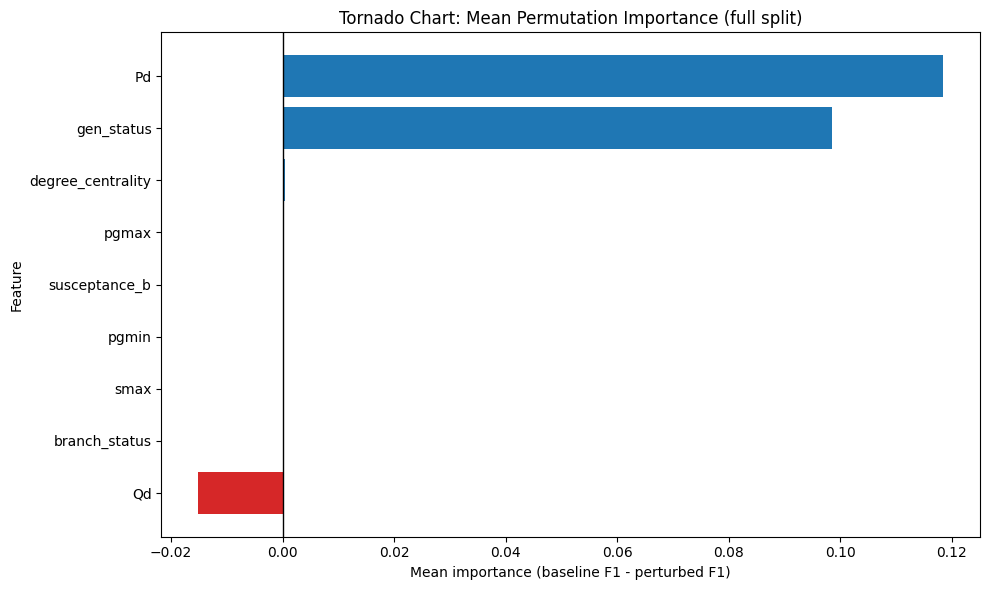

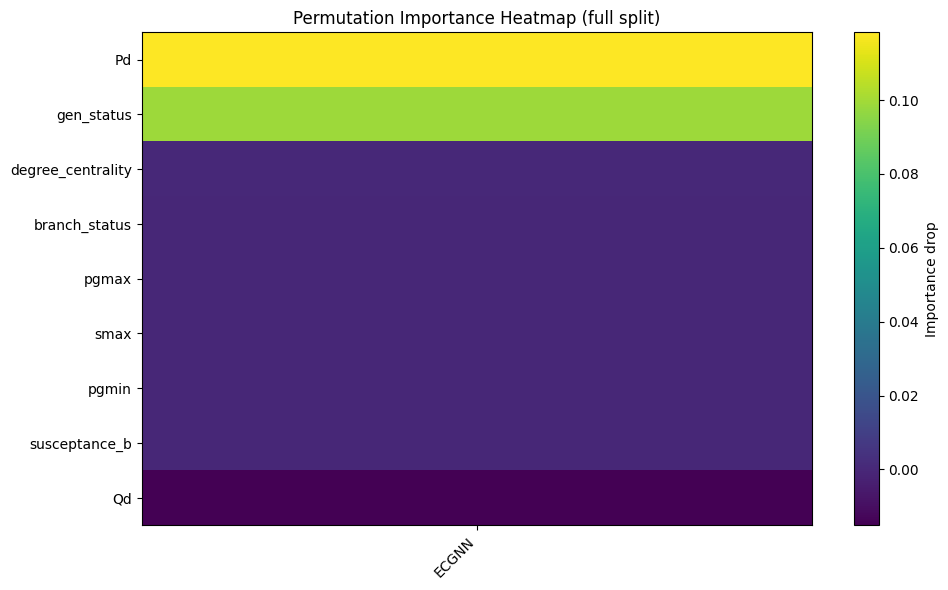

Saved outputs to: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\results\feature_importance


In [25]:
importance_pivot = feature_importance_summary.pivot(
    index="feature", columns="model", values="importance_drop"
).fillna(0.0)

# keep features ordered by average importance (high to low for table display)
importance_pivot = importance_pivot.loc[
    importance_pivot.mean(axis=1).sort_values(ascending=False).index
]
display(importance_pivot)

# tornado values: sorted low->high so bars spread around zero
tornado_values = importance_pivot.mean(axis=1).sort_values()
colors = np.where(tornado_values >= 0, "#1f77b4", "#d62728")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tornado_values.index, tornado_values.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Tornado Chart: Mean Permutation Importance ({EVALUATION_SPLIT} split)")
ax.set_xlabel("Mean importance (baseline F1 - perturbed F1)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(importance_pivot.values, aspect="auto", cmap="viridis")
plt.colorbar(label="Importance drop")
plt.xticks(
    range(len(importance_pivot.columns)),
    list(importance_pivot.columns),
    rotation=45,
    ha="right",
)
plt.yticks(range(len(importance_pivot.index)), list(importance_pivot.index))
plt.title(f"Permutation Importance Heatmap ({EVALUATION_SPLIT} split)")
plt.tight_layout()
plt.show()

importance_pivot.to_csv(results_dir / "feature_importance_pivot.csv")
print(f"Saved outputs to: {results_dir}")

## Cleaner Diagnostics for `branch_status`
These diagnostics separate three effects:
1. Metric masking effect (`mask = status`) vs no mask.
2. Outage-focused evaluation (only samples with at least one outaged branch).
3. Targeted `branch_status` perturbations on full and outage-only splits.

In [26]:
from torch.utils.data import Subset

def evaluate_f1_variant(model, loader, mask_with_status=True):
    model.eval()
    tp, fp, fn = 0.0, 0.0, 0.0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            y = batch.y.view(-1, 1)
            preds = (logits > 0).float()

            if mask_with_status:
                mask = batch.status.view(-1, 1)
                preds = preds * mask
                y = y * mask

            tp += ((preds == 1) & (y == 1)).float().sum().item()
            fp += ((preds == 1) & (y == 0)).float().sum().item()
            fn += ((preds == 0) & (y == 1)).float().sum().item()

    precision = tp / (tp + fp + 1e-8) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn + 1e-8) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall + 1e-8) if precision + recall > 0 else 0.0
    return {
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
    }

def build_outage_subset(selected_dataset):
    # Fast path: detect outages directly from CSV status columns without materializing each graph.
    if isinstance(selected_dataset, Subset):
        base_dataset = selected_dataset.dataset
        selected_indices = np.asarray(selected_dataset.indices, dtype=np.int64)
    else:
        base_dataset = selected_dataset
        selected_indices = np.arange(len(selected_dataset), dtype=np.int64)

    if hasattr(base_dataset, "df"):
        status_block = base_dataset.df.iloc[selected_indices, 91:171].to_numpy(copy=False)
        outage_mask = (status_block < 0.5).any(axis=1)
        outage_indices = selected_indices[outage_mask].tolist()
        outage_subset = Subset(base_dataset, outage_indices)
    else:
        outage_indices = []
        for idx in range(len(selected_dataset)):
            sample = selected_dataset[idx]
            if (sample.status.view(-1) < 0.5).any():
                outage_indices.append(idx)
        outage_subset = Subset(selected_dataset, outage_indices)

    outage_loader = DataLoader(
        cast(Sequence[BaseData], outage_subset),
        batch_size=FEATURE_IMPORTANCE_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )
    return outage_subset, outage_loader

outage_subset, outage_loader = build_outage_subset(eval_dataset)
print(f"Outage-only samples: {len(outage_subset)} / {len(eval_dataset)}")

baseline_rows = []
for model_name, model in trained_models.items():
    full_masked = evaluate_f1_variant(model, eval_loader, mask_with_status=True)
    full_unmasked = evaluate_f1_variant(model, eval_loader, mask_with_status=False)

    row = {
        "model": model_name,
        "full_masked_f1": full_masked["f1"],
        "full_unmasked_f1": full_unmasked["f1"],
        "full_masked_recall": full_masked["recall"],
        "full_unmasked_recall": full_unmasked["recall"],
    }

    if len(outage_subset) > 0:
        outage_masked = evaluate_f1_variant(model, outage_loader, mask_with_status=True)
        outage_unmasked = evaluate_f1_variant(model, outage_loader, mask_with_status=False)
        row.update({
            "outage_masked_f1": outage_masked["f1"],
            "outage_unmasked_f1": outage_unmasked["f1"],
            "outage_masked_recall": outage_masked["recall"],
            "outage_unmasked_recall": outage_unmasked["recall"],
        })

    baseline_rows.append(row)

diagnostic_baselines = pd.DataFrame(baseline_rows).sort_values("model").reset_index(drop=True)
display(diagnostic_baselines)
diagnostic_baselines.to_csv(results_dir / "diagnostic_baselines_masked_vs_unmasked.csv", index=False)
print(f"Saved: {results_dir / 'diagnostic_baselines_masked_vs_unmasked.csv'}")

Outage-only samples: 5070 / 10000


,model,full_masked_f1,full_unmasked_f1,full_masked_recall,full_unmasked_recall,outage_masked_f1,outage_unmasked_f1,outage_masked_recall,outage_unmasked_recall
0,ECGNN,0.327449,0.322381,0.795535,0.795535,0.260824,0.252169,0.757669,0.757669


Saved: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\results\feature_importance\diagnostic_baselines_masked_vs_unmasked.csv


In [27]:
def perturb_status_only(batch):
    return permute_edge_feature(batch, "status")

def force_all_status_on(batch):
    perturbed = batch.clone()
    perturbed.status = torch.ones_like(batch.status)
    return perturbed

status_diag_rows = []

for model_name, model in trained_models.items():
    full_baseline = evaluate_masked_f1(model, eval_loader)
    full_status_perm = estimate_permutation_importance(
        model, eval_loader, perturb_batch_fn=perturb_status_only, repeats=FEATURE_IMPORTANCE_REPEATS
    )
    full_force_on = estimate_permutation_importance(
        model, eval_loader, perturb_batch_fn=force_all_status_on, repeats=FEATURE_IMPORTANCE_REPEATS
    )

    row = {
        "model": model_name,
        "full_baseline_masked_f1": full_baseline,
        "full_status_perm_f1": full_status_perm[0],
        "full_status_perm_std": full_status_perm[1],
        "full_status_perm_drop": full_baseline - full_status_perm[0],
        "full_force_all_on_f1": full_force_on[0],
        "full_force_all_on_std": full_force_on[1],
        "full_force_all_on_drop": full_baseline - full_force_on[0],
    }

    if len(outage_subset) > 0:
        outage_baseline = evaluate_masked_f1(model, outage_loader)
        outage_status_perm = estimate_permutation_importance(
            model, outage_loader, perturb_batch_fn=perturb_status_only, repeats=FEATURE_IMPORTANCE_REPEATS
        )
        outage_force_on = estimate_permutation_importance(
            model, outage_loader, perturb_batch_fn=force_all_status_on, repeats=FEATURE_IMPORTANCE_REPEATS
        )
        row.update({
            "outage_baseline_masked_f1": outage_baseline,
            "outage_status_perm_f1": outage_status_perm[0],
            "outage_status_perm_std": outage_status_perm[1],
            "outage_status_perm_drop": outage_baseline - outage_status_perm[0],
            "outage_force_all_on_f1": outage_force_on[0],
            "outage_force_all_on_std": outage_force_on[1],
            "outage_force_all_on_drop": outage_baseline - outage_force_on[0],
        })

    status_diag_rows.append(row)

status_diagnostics = pd.DataFrame(status_diag_rows).sort_values("model").reset_index(drop=True)
display(status_diagnostics)
status_diagnostics.to_csv(results_dir / "diagnostic_branch_status_targeted.csv", index=False)
print(f"Saved: {results_dir / 'diagnostic_branch_status_targeted.csv'}")

,model,full_baseline_masked_f1,full_status_perm_f1,full_status_perm_std,full_status_perm_drop,full_force_all_on_f1,full_force_all_on_std,full_force_all_on_drop,outage_baseline_masked_f1,outage_status_perm_f1,outage_status_perm_std,outage_status_perm_drop,outage_force_all_on_f1,outage_force_all_on_std,outage_force_all_on_drop
0,ECGNN,0.327449,0.327409,0.00004,0.00004,0.327449,0.0,0.0,0.260824,0.260686,0.0,0.000138,0.260824,0.0,0.0


Saved: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\results\feature_importance\diagnostic_branch_status_targeted.csv
